In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error

# Load processed data
df = pd.read_csv('../data/processed/merged_clean.csv', parse_dates=['Date'])

print("✅ Data loaded:", df.shape)
print(df.head())

✅ Data loaded: (420285, 21)
   Store  Dept       Date  Weekly_Sales  IsHoliday Type    Size  Temperature  \
0      1     1 2010-02-05      24924.50      False    A  151315        42.31   
1      1     1 2010-02-12      46039.49       True    A  151315        38.51   
2      1     1 2010-02-19      41595.55      False    A  151315        39.93   
3      1     1 2010-02-26      19403.54      False    A  151315        46.63   
4      1     1 2010-03-05      21827.90      False    A  151315        46.50   

   Fuel_Price  MarkDown1  ...  MarkDown3  MarkDown4  MarkDown5         CPI  \
0       2.572        0.0  ...        0.0        0.0        0.0  211.096358   
1       2.548        0.0  ...        0.0        0.0        0.0  211.242170   
2       2.514        0.0  ...        0.0        0.0        0.0  211.289143   
3       2.561        0.0  ...        0.0        0.0        0.0  211.319643   
4       2.625        0.0  ...        0.0        0.0        0.0  211.350143   

   Unemployment  Year 

Times Series Length: 143
Date Range: 2010-02-05 00:00:00 to 2012-10-26 00:00:00


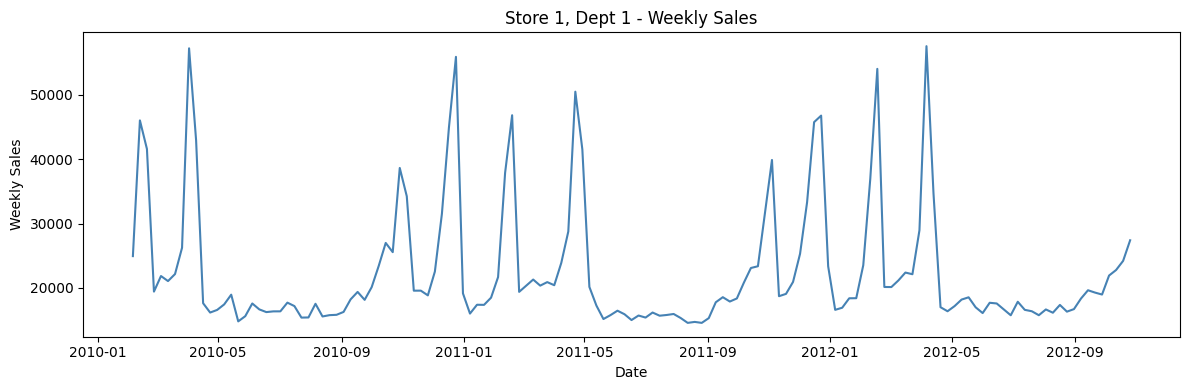

In [5]:
#preparing a single time series for ARIMA, one store and one department at a time.
store_id = 1
dept_id = 1

ts= df[(df['Store'] == store_id) & (df['Dept'] == dept_id)].copy()
ts= ts.sort_values('Date').set_index('Date')
ts=ts['Weekly_Sales']

print(f"Times Series Length: {len(ts)}")
print(f"Date Range: {ts.index.min()} to {ts.index.max()}")

#plot it
plt.figure(figsize=(12,4))
plt.plot(ts.index, ts.values, color='steelblue')
plt.title('Store 1, Dept 1 - Weekly Sales')
plt.xlabel('Date')
plt.ylabel('Weekly Sales')
plt.tight_layout()
plt.show()

Train size: 131 weeks
Test size: 12 weeks

 ARIMA MAE: $3,022.90


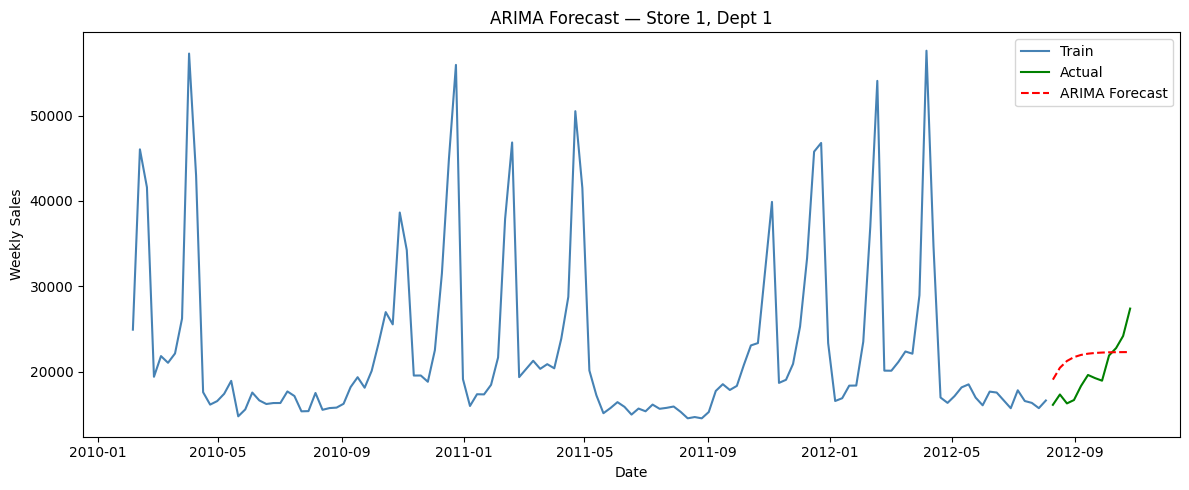

In [7]:
 #split data into train and test sets
train_size = len(ts) - 12
train_ts= ts.iloc[:train_size]
test_ts= ts.iloc[train_size:]

print(f"Train size: {len(train_ts)} weeks")
print(f"Test size: {len(test_ts)} weeks")

#Fit ARIMA Model (p=1, d=1, q=1) - standard starting point
model = ARIMA(train_ts, order=(1,1,1))
fitted= model.fit()

#forecast
forecast=fitted.forecast(steps=12)

#calculate MAE
mae= mean_absolute_error(test_ts, forecast)
print(f"\n ARIMA MAE: ${mae:,.2f}")

# Plot actual vs predicted
plt.figure(figsize=(12, 5))
plt.plot(train_ts.index, train_ts.values, label='Train', color='steelblue')
plt.plot(test_ts.index, test_ts.values, label='Actual', color='green')
plt.plot(test_ts.index, forecast, label='ARIMA Forecast', color='red', linestyle='--')
plt.title('ARIMA Forecast — Store 1, Dept 1')
plt.xlabel('Date')
plt.ylabel('Weekly Sales')
plt.legend()
plt.tight_layout()
plt.show()

MAE shows that on average the forecast is off by 3k per week. And the plot conveys that ARIMA is able to show an upward trend but the line goes flat, which tells us that it is missing the holiday trends. Lets try another model to see if it can perform better.

20:49:49 - cmdstanpy - INFO - Chain [1] start processing
20:49:51 - cmdstanpy - INFO - Chain [1] done processing


Prophet MAE: $1,702.75
ARIMA MAE:   $3,022.90


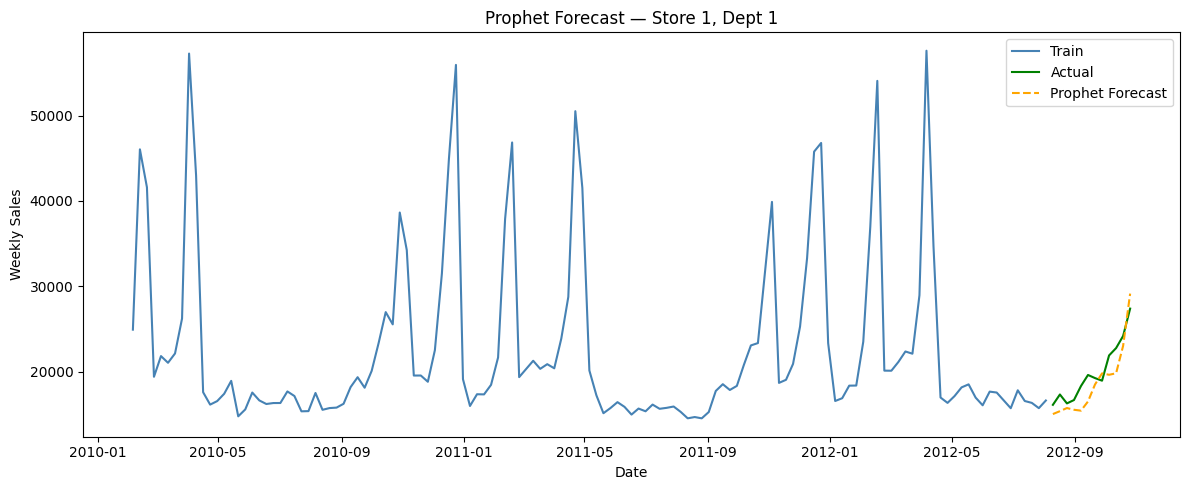

In [9]:
from prophet import Prophet

#Preophet requires columns named 'ds' and 'y'
prophet_df= ts.reset_index()
prophet_df.columns = ['ds','y']

#train test split
prophet_train= prophet_df.iloc[:train_size]
prophet_test= prophet_df.iloc[train_size:]

#fit model
m= Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
m.fit(prophet_train)

#Forecast
future= m.make_future_dataframe(periods=12, freq='W')
forecast_prophet= m.predict(future)

# Get test predictions
prophet_preds = forecast_prophet.iloc[train_size:]['yhat'].values
mae_prophet = mean_absolute_error(prophet_test['y'].values, prophet_preds)
print(f"Prophet MAE: ${mae_prophet:,.2f}")
print(f"ARIMA MAE:   ${mae:,.2f}")

# Plot
plt.figure(figsize=(12, 5))
plt.plot(prophet_train['ds'], prophet_train['y'], label='Train', color='steelblue')
plt.plot(prophet_test['ds'], prophet_test['y'], label='Actual', color='green')
plt.plot(prophet_test['ds'], prophet_preds, label='Prophet Forecast', color='orange', linestyle='--')
plt.title('Prophet Forecast — Store 1, Dept 1')
plt.xlabel('Date')
plt.ylabel('Weekly Sales')
plt.legend()
plt.tight_layout()
plt.show()

we see a clear jump is model performance! Prophet is 44% better in forecasting the future trend compared to ARIMA.

CONS: This comparision is still limited to 1 store-1 department. Both models still miss the sudden spikes from external events like hurricanes, supply shocks, unexpected holidays etc..

In [10]:
# Results summary
results = pd.DataFrame({
    'Model': ['ARIMA', 'Prophet'],
    'MAE': [mae, mae_prophet],
    'Store': [1, 1],
    'Dept': [1, 1]
})

print("=== Baseline Model Results ===")
print(results.to_string(index=False))
print(f"\nProphet improvement over ARIMA: {((mae - mae_prophet)/mae)*100:.1f}%")

=== Baseline Model Results ===
  Model         MAE  Store  Dept
  ARIMA 3022.900842      1     1
Prophet 1702.745793      1     1

Prophet improvement over ARIMA: 43.7%
